In [ ]:
!pip install roboflow ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 24.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="QThjfB4sjPBDi1eJfvsF")
project = rf.workspace("tesiscafe").project("funkos_0")
version = project.version(6)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to funkos_0-6 in yolov11:: 100%|██████████| 155/155 [00:00<00:00, 618.57it/s]


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    project="runs",
    name="funkos_yolo11",
    exist_ok=True
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/funkos_0-6/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, im

In [ ]:
metrics = model.val(
    imgsz=640,
    project="runs",
    name="funkos_yolo11_val",
    exist_ok=True,
    plots=True
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precisión por clase:", metrics.box.maps)


Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,032,345 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3781.2±1469.2 MB/s, size: 1537.6 KB)
val: Scanning /content/funkos_0-6/valid/labels.cache... 11 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11/11 5.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2s/it 1.2s
                   all         11         15      0.982          1      0.995      0.906
            Doc. Brown          5          5      0.978          1      0.995      0.925
           Gogeta SSJ4          4          4      0.976          1      0.995      0.964
       Michael Jackson          6          6       0.99          1      0.995       0.83
Speed: 1.5ms preprocess, 31.5ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/runs/funkos_

In [ ]:
import os
import pandas as pd

results_csv_path = os.path.join("runs","detect","runs", "funkos_yolo11", "results.csv")

df = pd.read_csv(results_csv_path)
df


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,30.6145,0.91004,3.40484,1.40812,0.09595,0.40000,0.10716,0.05712,0.78734,3.84499,1.27520,0.000043,0.000043,0.000043
1,2,33.6952,0.96716,3.22320,1.48406,0.38590,0.82222,0.69501,0.55933,0.83988,3.27545,1.37932,0.000097,0.000097,0.000097
2,3,38.1682,0.66175,1.71561,1.30729,0.91261,0.48189,0.64782,0.50953,0.80832,2.38327,1.42285,0.000147,0.000147,0.000147
3,4,41.5996,0.67730,1.67643,1.23733,0.71409,0.52778,0.53580,0.34183,1.10561,2.73718,1.64655,0.000193,0.000193,0.000193
4,5,44.9447,0.69475,1.11382,1.20855,0.70311,0.72369,0.74463,0.59289,0.81415,2.14424,1.40188,0.000236,0.000236,0.000236
5,6,49.6362,0.77937,1.13434,1.27608,0.68005,0.92803,0.91330,0.65900,0.89980,1.72996,1.39099,0.000274,0.000274,0.000274
6,7,56.2569,0.63960,0.90294,1.13069,0.78655,0.66094,0.76637,0.51751,1.13558,1.92201,1.54533,0.000309,0.000309,0.000309
7,8,59.8140,0.70761,0.92470,1.19316,0.25292,0.42778,0.27341,0.11376,2.26173,3.38576,3.02885,0.000341,0.000341,0.000341
8,9,66.5983,0.71856,0.91026,1.17172,0.61984,0.08333,0.10497,0.04253,2.88271,4.02271,3.54038,0.000368,0.000368,0.000368
9,10,70.0766,0.78230,0.82375,1.23683,0.10177,0.06667,0.03242,0.01846,2.96653,3.44229,3.55320,0.000392,0.000392,0.000392


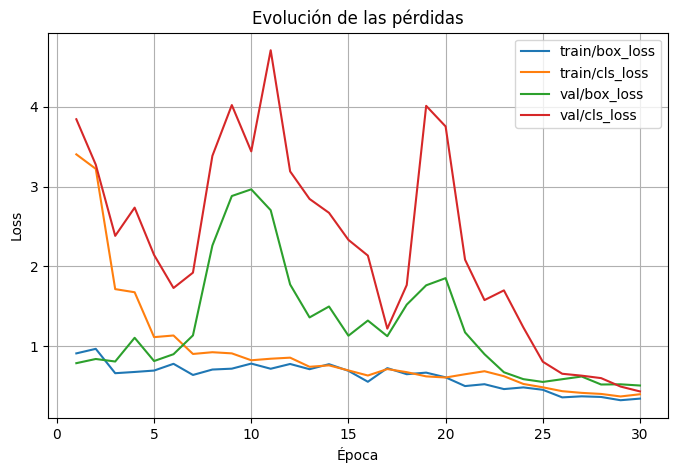

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="train/cls_loss")
plt.plot(df["epoch"], df["val/box_loss"], label="val/box_loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="val/cls_loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolución de las pérdidas")
plt.legend()
plt.grid(True)
plt.show()


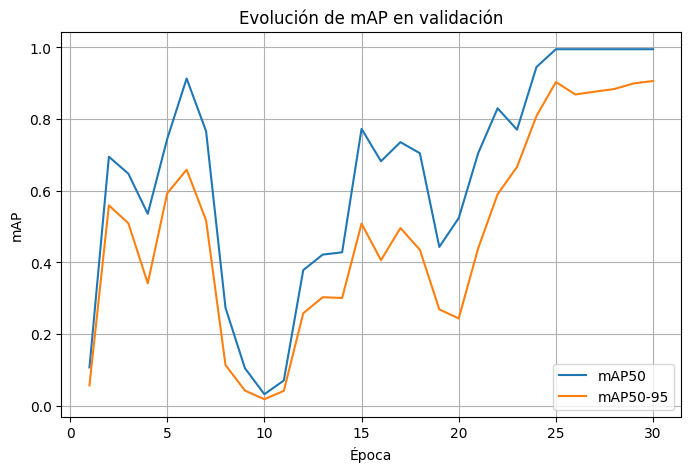

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Época")
plt.ylabel("mAP")
plt.title("Evolución de mAP en validación")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from IPython.display import Image, display

base_dir = os.path.join("runs", "funkos_yolo11")

for fname in ["confusion_matrix.png", "F1_curve.png", "PR_curve.png", "results.png"]:
    path = os.path.join(base_dir, fname)
    if os.path.exists(path):
        print(fname)
        display(Image(filename=path))
    else:
        print("No se encontró:", path)


No se encontró: runs/funkos_yolo11/confusion_matrix.png
No se encontró: runs/funkos_yolo11/F1_curve.png
No se encontró: runs/funkos_yolo11/PR_curve.png
No se encontró: runs/funkos_yolo11/results.png



image 1/1 /content/IMG_20251213_162146.jpg: 480x640 1 Doc. Brown, 1 Gogeta SSJ4, 1 Michael Jackson, 194.2ms
Speed: 19.1ms preprocess, 194.2ms inference, 6.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/runs/funkos_yolo11_pred
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Doc. Brown', 1: 'Gogeta SSJ4', 2: 'Michael Jackson'}
obb: None
orig_img: array([[[  7,   7,   7],
        [  9,   9,   9],
        [ 10,  10,  10],
        ...,
        [148, 138, 121],
        [129, 119, 101],
        [118, 108,  90]],

       [[  9,   9,   9],
        [ 10,  10,  10],
        [ 11,  11,  11],
        ...,
        [159, 149, 132],
        [145, 135, 117],
        [125, 115,  97]],

       [[ 11,  11,  11],
        [ 11,  11,  11],
        [ 12,  12,  12],
        ...,
        [162, 154, 137],
        [149, 141, 124],
        [125, 117, 100]],

       ...,

 

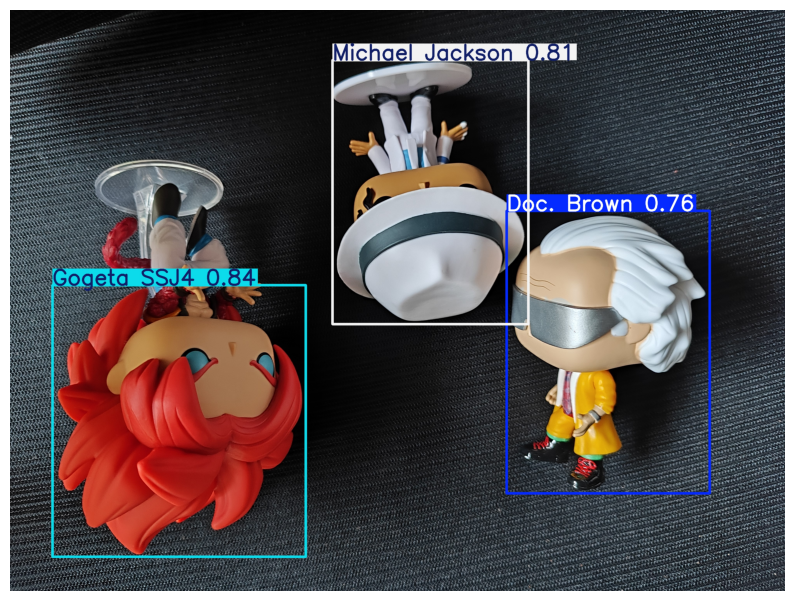

In [ ]:
import matplotlib.pyplot as plt
import cv2

img_path = "/content/IMG_20251213_162146.jpg"

preds = model.predict(
    source=img_path,
    imgsz=640,
    conf=0.5,
    save=True,
    project="runs",
    name="funkos_yolo11_pred",
    exist_ok=True
)

print(preds)

result_image_path = preds[0].save_dir + "/" + preds[0].path.split("/")[-1]

img = cv2.imread(result_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.show()


In [ ]:
preds[0][0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Doc. Brown', 1: 'Gogeta SSJ4', 2: 'Michael Jackson'}
obb: None
orig_img: array([[[120, 121, 119],
        [138, 139, 137],
        [ 81,  82,  80],
        ...,
        [ 59,  54,  53],
        [ 78,  73,  70],
        [ 70,  65,  62]],

       [[123, 124, 122],
        [138, 139, 137],
        [ 88,  89,  87],
        ...,
        [ 76,  71,  70],
        [105, 100,  97],
        [ 96,  91,  88]],

       [[130, 131, 129],
        [133, 134, 132],
        [ 84,  85,  83],
        ...,
        [102,  97,  96],
        [137, 132, 129],
        [118, 113, 110]],

       ...,

       [[129, 129, 129],
        [ 86,  86,  86],
        [ 84,  84,  84],
        ...,
        [ 77,  75,  75],
        [ 89,  87,  87],
        [ 94,  92,  92]],

       [[144, 144, 144],
        [101, 101, 101],
        [ 87,  87,  87],
        ...,
        [ 78,  76, 